In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightkurve as lk

import glob 
from tqdm import tqdm
from copy import deepcopy

from astropy.stats import sigma_clipped_stats

from sklearn.cluster import DBSCAN

from Kakapo.photometry import forced_photometry
from Kakapo.difference_image import create_diff_image
from Kakapo.cleaning_curve import _wavelet_denoise, correct_motion_lightcurve

%matplotlib widget

In [2]:
def _tpf_addition(tpf_info, tpf_input):
    
    if tpf_input.campaign is None:
        campaign = tpf_input.quarter
        mission = 'Kepler'
        print(f"Adding TPF {tpf_input.targetid} from {mission} quarter {campaign}")
    else:
        campaign = tpf_input.campaign
        mission = 'K2'
    
    tpf_info.loc[len(tpf_info)] = [mission, campaign, tpf_input.targetid, tpf_input.ra, tpf_input.dec, 
                                   tpf_input.flux.value, tpf_input.flux_err.value, tpf_input.quality, 
                                   tpf_input.pos_corr1, tpf_input.pos_corr2, tpf_input.time]
    
    return tpf_info

def _check_tpf_type(tpf_input):
    
    tpf_info = pd.DataFrame(columns=['mission', 'campaign', 'targetid', 'ra', 'dec', 'flux', 'flux_err', 
                                     'quality', 'pos_corr1', 'pos_corr2', 'time'])
        
    for i in range(len(tpf_input)):
        if isinstance(tpf_input[i], lk.targetpixelfile.KeplerTargetPixelFile):
            tpf_info = _tpf_addition(tpf_info, tpf_input[i])
        
    return tpf_info

In [3]:
def access_tpfs():
    """
    """

    test_case = []

    lightkurve_file_folder = '/Users/zgl12/.lightkurve/cache/mastDownload/K2/'

    files = sorted(glob.glob(lightkurve_file_folder + '*211553428*/*.fits.gz'))

    for file in tqdm(files, desc='Reading TPFs'):
        tpf = lk.read(file, quality_bitmask = 'none')
        test_case.append(tpf)
        
    return test_case

In [4]:
tpf = access_tpfs()
tpf_info = _check_tpf_type(tpf)
tpf_info

Reading TPFs: 100%|██████████| 1/1 [00:00<00:00,  4.13it/s]


,mission,campaign,targetid,ra,dec,flux,flux_err,quality,pos_corr1,pos_corr2,time
0,K2,16,211553428,131.265105,13.888741,"[[[1.8788357, 4.086992, 11.286907, 10.639399, ...","[[[1.3455712, 1.3411188, 1.3466251, 1.342577, ...","[524288, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0.19570653, 0.22161375, 0.24816677, 0.2687680...","[-0.05176155, -0.06471004, -0.07815906, -0.085...","[3262.4675920803274, 3262.4880274192255, 3262...."


In [5]:
tpf_info.iloc[0].flux

array([[[ 1.87883568e+00,  4.08699179e+00,  1.12869072e+01, ...,
          4.66234360e+01,  2.73016327e+02,  6.22262726e+01],
        [-1.05361662e+01,  1.96942055e+00,  1.94870701e+01, ...,
          8.43315125e+00,  3.00941353e+01,  1.55904312e+01],
        [ 2.22997427e+00,  6.28683758e+00,  3.73712196e+01, ...,
          1.03415937e+01,  5.69305182e+00, -1.00407529e+00],
        ...,
        [-5.46080053e-01, -1.45828533e+00,  6.58696079e+00, ...,
          1.05341845e+01, -7.01381862e-02,  3.98884916e+00],
        [-1.72157085e+00, -2.98545790e+00, -2.96202588e+00, ...,
          3.42640686e+00,  2.67453241e+00,  2.43152761e+00],
        [-1.08208644e+00, -5.04930735e+00, -3.31045985e+00, ...,
          1.15382814e+01,  1.93815446e+00,  2.38016987e+00]],

       [[ 1.08499086e+00,  3.18558788e+00,  9.29469395e+00, ...,
          3.99289551e+01,  2.62443176e+02,  6.63610229e+01],
        [-1.05155058e+01, -2.11793232e+00,  1.75069942e+01, ...,
          8.19735527e+00,  3.15462513e

In [6]:
# 3.37, 2.44

flux = forced_photometry(tpf_info.iloc[0].flux, 3.37, 2.44, None)

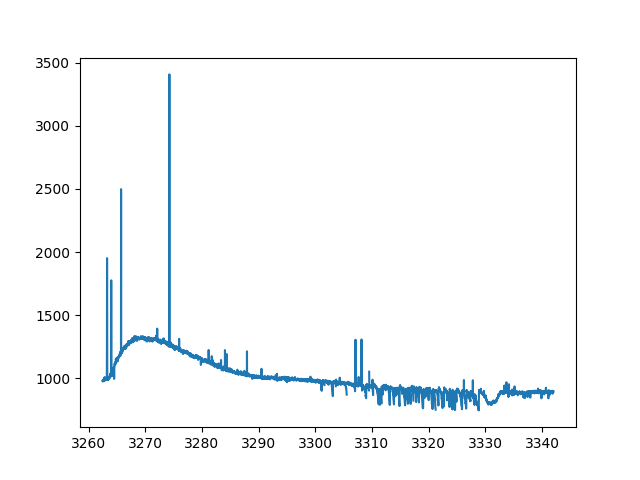

In [10]:
plt.figure()
plt.plot(tpf_info.iloc[0].time.value, flux)
plt.show()

In [8]:
tpf_info.iloc[0].time

<Time object: scale='tdb' format='bkjd' value=[3262.46759208 3262.48802742 3262.50846286 ... 3341.98194433 3342.00237927
 3342.0228141 ]>